In [11]:
import time
import logging
from typing import Tuple, Dict
from collections import namedtuple
import copy
import pickle

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from scipy.stats import norm
from matplotlib import pyplot as plt
from sklearn import tree
from scipy.stats import ks_2samp

from tqdm import tqdm

from common import *
from common import get_density_ratio_from_classifier
from data_loader import DataLoader, train_test_loader_split
from estimate_datashifter import DetectorTestExplainer, OUTCOME_MODEL_ARGS
from decomp_explainer import InferenceResult, ExplainerInference
from common import RevisedModel

SPLIT_RATIO = 0.5

In [7]:
def get_bootstrap_metric(Y_true, Y_pred, Y_prob, n_bootstrap=1000, alpha=0.05, rng_seed=0):
    """
    Bootstrap estimate of accuracy and AUC
    """
    rng = np.random.RandomState(rng_seed)
    indices = rng.randint(0, len(Y_true), (n_bootstrap, len(Y_true)))
    Y_true_boot = Y_true[indices]
    Y_pred_boot = Y_pred[indices]
    Y_prob_boot = Y_prob[indices]
    
    acc = np.mean(Y_true_boot == Y_pred_boot, axis=1)
    auc = np.array([roc_auc_score(Y_true_boot[i], Y_prob_boot[i]) for i in range(n_bootstrap)])
    
    results = {
        'acc': np.quantile(acc, q=[alpha/2, 0.5, 1-alpha/2]),
        'auc': np.quantile(auc, q=[alpha/2, 0.5, 1-alpha/2])
    }
    return results

def get_acc_auc(model, X, Y):
    Y = Y.flatten().astype(int)
    pred_prob = model.predict_proba(X)[:,1]
    pred_Y = model.predict(X).flatten().astype(int)
    assert len(X)==len(Y), "X, Y should be of same shape"
    conf_intervals = get_bootstrap_metric(Y, pred_Y, pred_prob, n_bootstrap=1000, alpha=0.05)  # format is (alpha/2, 0.5, 1-alpha/2) quartiles
    performances = {
        'acc': [(pred_Y == Y).mean()],
        'acc_lower': [conf_intervals['acc'][0]],
        'acc_upper': [conf_intervals['acc'][2]],
        'auc': [roc_auc_score(Y, pred_prob)],
        'auc_lower': [conf_intervals['auc'][0]],
        'auc_upper': [conf_intervals['auc'][2]],
    }  # each value is a list so it in can be converted to dataframe
    return performances

def get_detectors(explainer_data, data: DataLoader=None, feature_names=None):
    detector_x_fn, detector_y_fn = None, None
    tree_importance_x, tree_importance_y = None, None
    with open(explainer_data, 'rb') as f:
        detectors = pickle.load(f)
    correlated_features = detectors['agg_correlated_features']

    if len(detectors['agg_detectors_x']) > 0:
        detector_x, omega = detectors['agg_detectors_x'][0]
        def detector_x_fn(data_loader):
            data_loader = data_loader.copy()
            data_loader.subset_X(correlated_features)
            return detector_x.predict(data_loader, omega) > 0
        # detector_x_fn = lambda data_loader: detector_x.predict(data_loader, omega) > 0
        tree_importance_x = get_tree_importance_fitted(detector_x_fn, data)
        tree_importance_x = pd.DataFrame({'feature': feature_names, 'importance': tree_importance_x})
        tree_importance_x = tree_importance_x.sort_values(by='importance', ascending=False)
    if len(detectors['agg_detectors_y']) > 0:
        detector_y = detectors['agg_detectors_y'][0]  # Take only 1 detector
        tree_importance_y = detector_y.feature_importances_
        detector_y_fn = lambda data_loader: detector_y.predict(data_loader.X) > 0
        tree_importance_y = pd.DataFrame({'feature': feature_names, 'importance': tree_importance_y})
        tree_importance_y = tree_importance_y.sort_values(by='importance', ascending=False)
    return detector_x_fn, detector_y_fn, tree_importance_x, tree_importance_y

def get_tree_importance_fitted(detector_x, data: DataLoader):
    if data is None or len(np.unique(detector_x(data))) < 2:
        return None
    mdl = GradientBoostingClassifier(max_depth=2, n_estimators=200)
    mdl.fit(data.X, detector_x(data))
    return mdl.feature_importances_

def get_acc_detected(ml_mdl, detector, source_loader, target_loader, threshold=0.5):
    source_mask = detector(source_loader)
    target_mask = detector(target_loader)
    acc_detected_source = get_acc_auc(ml_mdl, source_loader.mdl_X[source_mask], source_loader.Y[source_mask], threshold)
    acc_detected_target = get_acc_auc(ml_mdl, target_loader.mdl_X[target_mask], target_loader.Y[target_mask], threshold)
    return acc_detected_source, acc_detected_target, source_mask, target_mask

In [36]:
explainer_data = '/Volumes/jhong9_SHIELD_shared/for_jean/model_data/_output/explain_score_test/shield_nonzero_covariate_planneddose_save/GradientBoostingClassifier/accuracy/0/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Cond_Cov'
tolerance = 0.0
grouping_data = '/Volumes/jhong9_SHIELD_shared/for_jean/model_data/shield_feature_groupings_drop_missing_nonzero_discretize_planneddose.csv'
train_data = '/Volumes/jhong9_SHIELD_shared/for_jean/model_data/duke_train_drop_missing_nonzero_discretize_planneddose.csv'
source_data = '/Volumes/jhong9_SHIELD_shared/for_jean/model_data/duke_test_drop_missing_nonzero_discretize_planneddose.csv'
target_data = '/Volumes/jhong9_SHIELD_shared/for_jean/model_data/ucsf_drop_missing_nonzero_discretize_planneddose.csv'
mdl_file = '/Volumes/jhong9_SHIELD_shared/for_jean/model_data/_output/explain_score_test/shield_nonzero_covariate_planneddose_save/GradientBoostingClassifier/mdl.pkl'

In [32]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/silent_study_jan_agg_all_detect/CatBoostClassifier/ppv/0.02/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Agg'
tolerance = 0.02
grouping_data = '/Volumes/BisharaA_IRB_17_23204_shared/data/drift_data/feature_groupings_groups_top_features.csv'
train_data = '/Volumes/BisharaA_IRB_17_23204_shared/data/drift_data/train_data_jan_top_features.csv'
source_data = '/Volumes/BisharaA_IRB_17_23204_shared/data/drift_data/valid_data_jan_top_features.csv'
target_data = '/Volumes/BisharaA_IRB_17_23204_shared/data/drift_data/target_data_jan_top_features.csv'
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/silent_study_jan_agg_all_detect/CatBoostClassifier/mdl.pkl'

In [20]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_linear_std_class/accuracy/0.05/40/8000/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Cond_Outcome'
tolerance = 0.05
grouping_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation/feature_grouping_dim4_norm1.csv'
train_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_linear_std_class/source_train_data1.csv'
source_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_linear_std_class/8000/source_data1.csv'
target_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_linear_std_class/8000/target_data1.csv'
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_linear_std_class/mdl.pkl'

In [121]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/modelfix/_output/acs_pubcov_save_scaled/accuracy/0.05/40/explainer1.pkl'
targeted_explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_save_scaled/MLPClassifier/accuracy/0.05/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Agg'
tolerance = 0.05
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_feature_groupings.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_train.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_val.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_target.csv"
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/modelfix/revised_mdl_nontargeted.pkl'

In [ ]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_save_scaled/MLPClassifier/accuracy/0.05/40/explainer1.pkl'
# explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_save_mdl_nocalib/MLPClassifier/accuracy/0.05/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Cond_Outcome'
tolerance = 0.05
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_feature_groupings.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_train.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_val.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_target.csv"
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_save_scaled/MLPClassifier/mdl.pkl'

In [2]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_covariate_scaled/MLPClassifier/accuracy/0.05/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Cond_Cov'
tolerance = 0.05
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_feature_groupings.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_train.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_val.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_target.csv"
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_covariate_scaled/MLPClassifier/mdl.pkl'

In [22]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_norm2_std_class/accuracy/0.02/40/500/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Cond_Cov'
tolerance = 0.02
grouping_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation/feature_grouping_dim4_norm1.csv'
train_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_norm2_std_class/source_train_data1.csv'
source_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_norm2_std_class/500/source_data1.csv'
target_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_norm2_std_class/500/target_data1.csv'
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_comparators/_output/dim4_norm2_std_class/mdl.pkl'

In [3]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/readmission_ucsf_zsfg_save/GradientBoostingClassifier/accuracy/0.02/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Cond_Cov'
tolerance = 0.02
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/hf_feature_groupings_filter_trim.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/ucsf_train_filter_trim.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/ucsf_test_filter_trim.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/zsfg_data_filter_trim.csv"
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/readmission_ucsf_zsfg_save/GradientBoostingClassifier/mdl.pkl'

In [11]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/readmission_ucsf_zsfg_flip_ptrim_outcome/GradientBoostingClassifier/accuracy/0.02/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Cond_Cov'
tolerance = 0.02
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/hf_feature_groupings_filter_trim.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/ucsf_train_filter_trim.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/ucsf_test_filter_trim.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/zsfg_data_filter_trim.csv"
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/readmission_ucsf_zsfg_flip_ptrim_outcome/GradientBoostingClassifier/mdl.pkl'

In [84]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_linear_aggbiggergroupratioeighty/accuracy/0.0/40/2000/explainerJOB.pkl'
num_jobs = 50
loss = 'accuracy'
decomposition = 'Cond_Outcome'
tolerance = 0.0
grouping_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation/feature_grouping_dim4_norm1.csv'
train_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg_output/dim10_linear_aggbiggergroupratioeighty/source_train_data1.csv'
source_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_linear_aggbiggergroupratioeighty/2000/source_dataJOB.csv'
target_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_linear_aggbiggergroupratioeighty/2000/target_dataJOB.csv'
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_linear_aggbiggergroupratioeighty/mdl.pkl'

In [93]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_norm2_aggsubgroupsmallcoeff/accuracy/0.0/40/2000/explainerJOB.pkl'
num_jobs = 50
loss = 'accuracy'
decomposition = 'Cond_Cov'
tolerance = 0.0
grouping_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation/feature_grouping_dim4_norm1.csv'
train_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg_output/dim10_norm2_aggsubgroupsmallcoeff/source_train_data1.csv'
source_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_norm2_aggsubgroupsmallcoeff/2000/source_dataJOB.csv'
target_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_norm2_aggsubgroupsmallcoeff/2000/target_dataJOB.csv'
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/simulation_agg/_output/dim10_norm2_aggsubgroupsmallcoeff/mdl.pkl'

In [37]:
def get_data_loaders(train_data, source_data, target_data, explainer_data, grouping_data, mdl_file, loss):
    chosen_threshold = 0.5

    _, trainY = read_csv(train_data)
    trainY = trainY.to_numpy()
    sourceX, sourceY = read_csv(source_data)
    features = sourceX.columns
    sourceX, sourceY = sourceX.to_numpy(), sourceY.to_numpy()
    targetX, targetY = read_csv(target_data)
    targetX, targetY = targetX.to_numpy(), targetY.to_numpy()
    class_weight = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=trainY)

    print("Datasets size train %d source %d target %d dims %d" % (len(trainY), len(sourceX), len(targetX), targetX.shape[1]))
    print("Class proportions train %.3f source %.3f target %.3f" % (trainY.mean(), sourceY.mean(), targetY.mean()))
        
    variable_dict = read_groupings(grouping_data)

    source_loader = DataLoader(sourceX, sourceY, variable_dict)
    target_loader = DataLoader(targetX, targetY, variable_dict)

    with open(mdl_file, "rb") as f:
        ml_mdl = pickle.load(f)

    loss_func = LossEvaluator(loss, ml_mdl, class_weight=class_weight, threshold=chosen_threshold).get_loss

    if loss == 'ppv':
        # Keep only rows that are predicted to be positive
        keep_indices_source = ml_mdl.predict_proba(sourceX)[:,1] > chosen_threshold
        keep_indices_target = ml_mdl.predict_proba(targetX)[:,1] > chosen_threshold
    else:
        keep_indices_source, keep_indices_target = np.ones(sourceX.shape[0], dtype=bool), np.ones(targetX.shape[0], dtype=bool)

    source_loader = DataLoader(sourceX[keep_indices_source], sourceY[keep_indices_source], variable_dict)
    target_loader = DataLoader(targetX[keep_indices_target], targetY[keep_indices_target], variable_dict)
    logging.info("NUM N source %d target %d, NUM P %d", source_loader.num_n, target_loader.num_n, source_loader.num_p)

    source_loss = loss_func(source_loader._get_X(), source_loader._get_Y()).mean()
    target_loss = loss_func(target_loader._get_X(), target_loader._get_Y()).mean()
    logging.info("TOTAL LOSS DIFF: %f - %f = %f", target_loss, source_loss, target_loss - source_loss)

    with open(explainer_data, 'rb') as f:
        detectors = pickle.load(f)
    correlated_features = detectors['agg_correlated_features']

    return source_loader, target_loader, ml_mdl, features, correlated_features, detectors["agg_detectors_x"], detectors["agg_detectors_y"]

def get_detections_outcome(explainer_data, X):
    with open(explainer_data, "rb") as f:
        detectors = pickle.load(f)
    detector_y = detectors['agg_detectors_y'][0]
    detection = detector_y.predict(X)
    return detection

# ACS

In [4]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/online/acs_pubcov_correlate/MLPClassifier/accuracy/0.05/0.05/40/Cond_Cov/explainer1.pkl'
loss = 'accuracy'
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_feature_groupings.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_train.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_val.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_target.csv"
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/online/acs_pubcov_correlate/MLPClassifier/mdl.pkl'

In [ ]:
source_loader, target_loader, ml_mdl, features, correlated_features, _, _ = get_data_loaders(train_data, source_data, target_data, explainer_data, grouping_data, mdl_file, loss)

X    SEX  AGEP  DIS  ESP  MIG  MIL  ANC  NATIVITY  DEAR  DEYE  ...  CIT_pr  \
0  1.0  15.0  2.0  2.0  1.0  0.0  1.0       2.0   2.0   2.0  ...     0.0   
1  2.0  60.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
2  1.0  30.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
3  2.0  59.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
4  2.0  31.0  2.0  0.0  1.0  4.0  4.0       1.0   2.0   2.0  ...     0.0   

   CIT_abroad  CIT_citizen  CIT_not  ESR_employed  ESR_partial_employed  \
0         0.0          0.0      1.0           0.0                   0.0   
1         0.0          0.0      0.0           0.0                   0.0   
2         0.0          0.0      0.0           1.0                   0.0   
3         0.0          0.0      0.0           1.0                   0.0   
4         0.0          0.0      0.0           1.0                   0.0   

   ESR_unemployed  ESR_armed  ESR_partial_armed  ESR_no  
0             0.0        0.0    

In [6]:
detector_x, detector_y, tree_importance_x, tree_importance_y = get_detectors(explainer_data, target_loader, features)

DATALOADER NUM_P [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] 34 {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33}
DATALOADER NUM_P [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] 34 {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33}


In [7]:
# Outcome

def get_subgroup(data):
    return (
        (data.X[:, 30] > 0.5) |  # Employment status unemployed
        ((data.X[:, 3] > 3.5) & (data.X[:, 3] < 6.5))  # Employment status of parents is Living with two parents: Neither parent in labor force
    )

subgroup = get_subgroup(source_loader)
np.mean(subgroup), np.sum(subgroup)

(0.04990524320909665, 158)

In [8]:
subgroup = get_subgroup(target_loader)
np.mean(subgroup), np.sum(subgroup)

(0.06641666666666667, 797)

In [1]:
0.860977 - 0.666996

0.19398099999999996

# ACS model update non targeted

In [21]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/modelfix/_output/acs_pubcov_save_scaled_nontargeted/accuracy/0.05/40/explainer1.pkl'
targeted_explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_save_scaled/MLPClassifier/accuracy/0.05/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Agg'
tolerance = 0.05
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_feature_groupings.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_train.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_val.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_target_modelfix.csv"
target_seed = 1  # fix the test dataset used to compute AUC of revised models in target_model_fix_seed ipython files
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/modelfix/fullfeatures_revised_mdl_nontargeted.pkl'

In [23]:
source_loader, target_loader, ml_mdl, features, correlated_features, detectors_x, detectors_y = get_data_loaders(train_data, source_data, target_data, explainer_data, grouping_data, mdl_file, loss)
detector_x, omega = detectors_x[0]  # take one detector
detector_y = detectors_y[0]  # take one detector

train_target_loader, test_target_loader = train_test_loader_split(
    target_loader, test_size = SPLIT_RATIO, random_state=target_seed
)

X    SEX  AGEP  DIS  ESP  MIG  MIL  ANC  NATIVITY  DEAR  DEYE  ...  CIT_pr  \
0  1.0  15.0  2.0  2.0  1.0  0.0  1.0       2.0   2.0   2.0  ...     0.0   
1  2.0  60.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
2  1.0  30.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
3  2.0  59.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
4  2.0  31.0  2.0  0.0  1.0  4.0  4.0       1.0   2.0   2.0  ...     0.0   

   CIT_abroad  CIT_citizen  CIT_not  ESR_employed  ESR_partial_employed  \
0         0.0          0.0      1.0           0.0                   0.0   
1         0.0          0.0      0.0           0.0                   0.0   
2         0.0          0.0      0.0           1.0                   0.0   
3         0.0          0.0      0.0           1.0                   0.0   
4         0.0          0.0      0.0           1.0                   0.0   

   ESR_unemployed  ESR_armed  ESR_partial_armed  ESR_no  
0             0.0        0.0    

In [25]:
# Accuracy of revised model on all target data
acc_nontargeted = get_acc_auc(ml_mdl, test_target_loader.X, test_target_loader.Y)
print("Accuracy on all target\n", pd.DataFrame(acc_nontargeted))

Accuracy on all target
         acc  acc_lower  acc_upper       auc  auc_lower  auc_upper
0  0.695902   0.677859   0.713115  0.730094   0.710327     0.7498


In [26]:
data_loader = test_target_loader.copy()
data_loader.subset_X(correlated_features)
nontargeted_detections_mask = detector_x.predict(test_target_loader, omega) > 0
nontargeted_detections_mask.mean()

DATALOADER NUM_P [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] 34 {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33}


0.052868852459016395

In [27]:
# Group addressed by targeted model which is the detected group for original model
targeted_group_mask = get_detections_outcome(targeted_explainer_data, test_target_loader.X) > 0
targeted_group_mask.mean()

0.5032786885245901

In [29]:
# Detections among the data not belonging to the targeted group
detections_from_remaining_mask = ~targeted_group_mask & nontargeted_detections_mask
print("remaining group size %.2f prevalence %.2f" % (sum(detections_from_remaining_mask), detections_from_remaining_mask.mean()))

remaining group size 44.00 prevalence 0.02


In [30]:
# Accuracy of nontargeted revision on detected group in remaining data
acc_remaining_nontargeted = pd.DataFrame(get_acc_auc(
    ml_mdl, 
    test_target_loader.X[detections_from_remaining_mask], 
    test_target_loader.Y[detections_from_remaining_mask]
))
print("Accuracy nontargeted revision on detected group in remaining data\n", (pd.DataFrame(acc_remaining_nontargeted) * 100).round(1))

Accuracy nontargeted revision on detected group in remaining data
     acc  acc_lower  acc_upper   auc  auc_lower  auc_upper
0  43.2       27.3       56.8  41.8       24.6       59.2


In [31]:
# Accuracy of original model on detected group in remaining data
acc_remaining_original = pd.DataFrame(get_acc_auc(
    ml_mdl.org_mdl,
    test_target_loader.X[detections_from_remaining_mask],
    test_target_loader.Y[detections_from_remaining_mask]
))
print("Accuracy original model on detected group in remaining data\n", (pd.DataFrame(acc_remaining_original) * 100).round(1))

Accuracy original model on detected group in remaining data
     acc  acc_lower  acc_upper   auc  auc_lower  auc_upper
0  65.9       52.3       79.5  66.4       46.8       83.6


/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/common.py:215: RuntimeWarning: invalid value encountered in divide
  ppv = np.sum(Y_true_boot & Y_pred_boot, axis=1) / np.sum(Y_pred_boot, axis=1)


# ACS model update as per TEVIM

In [34]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/modelfix/_output/acs_pubcov_save_scaled_tevim/accuracy/0.05/40/explainer1.pkl'
targeted_explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/_output/acs_pubcov_save_scaled/MLPClassifier/accuracy/0.05/40/explainer1.pkl'
loss = 'accuracy'
decomposition = 'Agg'
tolerance = 0.05
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_feature_groupings.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_train.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_source_val.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/data/acs_pubcov_target_modelfix.csv"
target_seed = 1  # fix the test dataset used to compute AUC of revised models in target_model_fix_seed ipython files
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/modelfix/tevim_revised_mdl_targeted.pkl'

In [36]:
source_loader, target_loader, ml_mdl, features, correlated_features, detectors_x, detectors_y = get_data_loaders(train_data, source_data, target_data, explainer_data, grouping_data, mdl_file, loss)
detector_x, omega = detectors_x[0]  # take one detector
detector_y = detectors_y[0]  # take one detector

train_target_loader, test_target_loader = train_test_loader_split(
    target_loader, test_size = SPLIT_RATIO, random_state=target_seed
)

X    SEX  AGEP  DIS  ESP  MIG  MIL  ANC  NATIVITY  DEAR  DEYE  ...  CIT_pr  \
0  1.0  15.0  2.0  2.0  1.0  0.0  1.0       2.0   2.0   2.0  ...     0.0   
1  2.0  60.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
2  1.0  30.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
3  2.0  59.0  2.0  0.0  1.0  4.0  2.0       1.0   2.0   2.0  ...     0.0   
4  2.0  31.0  2.0  0.0  1.0  4.0  4.0       1.0   2.0   2.0  ...     0.0   

   CIT_abroad  CIT_citizen  CIT_not  ESR_employed  ESR_partial_employed  \
0         0.0          0.0      1.0           0.0                   0.0   
1         0.0          0.0      0.0           0.0                   0.0   
2         0.0          0.0      0.0           1.0                   0.0   
3         0.0          0.0      0.0           1.0                   0.0   
4         0.0          0.0      0.0           1.0                   0.0   

   ESR_unemployed  ESR_armed  ESR_partial_armed  ESR_no  
0             0.0        0.0    

In [38]:
# Accuracy of revised model on all target data
acc_nontargeted = get_acc_auc(ml_mdl, test_target_loader.X, test_target_loader.Y)
print("Accuracy on all target\n", pd.DataFrame(acc_nontargeted))

Accuracy on all target
         acc  acc_lower  acc_upper       auc  auc_lower  auc_upper
0  0.688525   0.670902   0.707387  0.730212   0.709906   0.750983


In [44]:
nontargeted_detections_mask = get_detections_outcome(explainer_data, test_target_loader.X) > 0
# data_loader = test_target_loader.copy()
# data_loader.subset_X(correlated_features)
# nontargeted_detections_mask = detector_x.predict(test_target_loader, omega) > 0
nontargeted_detections_mask.mean()

0.49221311475409835

In [45]:
# Group addressed by targeted model which is the detected group for original model
targeted_group_mask = get_detections_outcome(targeted_explainer_data, test_target_loader.X) > 0
targeted_group_mask.mean()

0.5032786885245901

In [46]:
# Detections among the data not belonging to the targeted group
detections_from_remaining_mask = ~targeted_group_mask & nontargeted_detections_mask
print("remaining group size %.2f prevalence %.2f" % (sum(detections_from_remaining_mask), detections_from_remaining_mask.mean()))

remaining group size 300.00 prevalence 0.12


In [47]:
# Accuracy of targeted revision as per TEVIM on detected group in remaining data
acc_remaining_nontargeted = pd.DataFrame(get_acc_auc(
    ml_mdl, 
    test_target_loader.X[detections_from_remaining_mask], 
    test_target_loader.Y[detections_from_remaining_mask]
))
print("Accuracy nontargeted revision on detected group in remaining data\n", (pd.DataFrame(acc_remaining_nontargeted) * 100).round(1))

Accuracy nontargeted revision on detected group in remaining data
     acc  acc_lower  acc_upper   auc  auc_lower  auc_upper
0  66.7       61.3       71.7  63.7       56.6       70.5


In [48]:
# Accuracy of original model on detected group in remaining data
acc_remaining_original = pd.DataFrame(get_acc_auc(
    ml_mdl.org_mdl,
    test_target_loader.X[detections_from_remaining_mask],
    test_target_loader.Y[detections_from_remaining_mask]
))
print("Accuracy original model on detected group in remaining data\n", (pd.DataFrame(acc_remaining_original) * 100).round(1))

Accuracy original model on detected group in remaining data
     acc  acc_lower  acc_upper   auc  auc_lower  auc_upper
0  67.7       62.3       72.7  65.0       57.5       71.5


# UCSF - ZSFG readmission

In [10]:
explainer_data = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/online/readmission_ucsf_zsfg_correlate/GradientBoostingClassifier/accuracy/0.02/0.05/40/Cond_Cov/explainer1.pkl'
loss = 'accuracy'
grouping_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/hf_feature_groupings_filter_trim.csv"
train_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/ucsf_train_filter_trim.csv"
source_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/ucsf_test_filter_trim.csv"
target_data = "/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_perf_changes/data/zsfg_data_filter_trim.csv"
mdl_file = '/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/src/casestudy/online/readmission_ucsf_zsfg_correlate/GradientBoostingClassifier/mdl.pkl'

In [11]:
source_loader, target_loader, ml_mdl, features, correlated_features = get_data_loaders(train_data, source_data, target_data, explainer_data, grouping_data, mdl_file, loss)

X    num_ed_encounters  ageinyears  firstrace_Asian  \
0                0.0        69.0              0.0   
1                1.0        64.0              1.0   
2                1.0        36.0              0.0   
3                0.0        43.0              0.0   
4                1.0        71.0              0.0   

   firstrace_Black or African American  \
0                                  0.0   
1                                  0.0   
2                                  1.0   
3                                  0.0   
4                                  0.0   

   firstrace_Native American or Alaska Native  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                         0.0   

   firstrace_Native Hawaiian or Other Pacific Islander  firstrace_White  \
0                                                0.0    

In [13]:
# Outcome

def get_subgroup(data):
    return (
        ((data.X[:, 0] > 2) & (data.X[:, 0] < 5))  # number of ED encounters
    )

subgroup = get_subgroup(source_loader)
np.mean(subgroup), np.sum(subgroup)

(0.08061060524906266, 602)

In [15]:
subgroup = get_subgroup(target_loader)
np.mean(subgroup), np.sum(subgroup)

(0.12340752110514198, 804)

In [16]:
0.871901 - 0.717902

0.153999

In [24]:
acc_detected_source, acc_detected_target = get_acc_detected(ml_mdl, detector_y, sourceX, sourceY, targetX, targetY)

In [46]:
pd.DataFrame(acc_detected_source)

,acc,acc_lower,acc_upper,auc,auc_lower,auc_upper
0,0.906739,0.897413,0.916366,0.788717,0.764378,0.812556


In [26]:
pd.DataFrame(acc_detected_target)

,acc,acc_lower,acc_upper,auc,auc_lower,auc_upper
0,0.906918,0.886792,0.925818,0.591219,0.496778,0.674747


In [48]:
# Difference in accuracy of the detected subgroup
acc_detected_target['acc'][0] - acc_detected_source['acc'][0]

-0.09595300810408225

In [28]:
sourceX[sourceX[:,0] >= 1.5].shape[0] / len(sourceX)

0.414

In [29]:
targetX[targetX[:,0] >= 1.5].shape[0] / len(targetX)

0.07

In [9]:
shift_explainer = DetectorTestExplainer(
    source_loader=source_loader,
    target_loader=target_loader,
    source_data_generator=None,
    target_data_generator=None,
    loss_func=loss_func,
    ml_mdl=ml_mdl,
    num_bins=num_bins,
    do_grid_search=do_grid_search,
    do_clipping=do_clipping,
    gridsearch_polynom_lr=gridsearch_polynom_lr,
    is_oracle=is_oracle,
    tolerance=tolerance,
    prevalence=prevalence,
    test_greater=do_test_greater)

outcome model (binary True) GridSearchCV(cv=3,
             estimator=PipelineWeightedFit(steps=[('clf',
                                                   RandomForestClassifier())]),
             n_jobs=1,
             param_grid=[{'clf': (RandomForestClassifier(criterion='log_loss',
                                                         max_depth=16,
                                                         n_estimators=400,
                                                         n_jobs=-1,
                                                         random_state=0),),
                          'clf__max_depth': [2, 4, 6, 8, 16],
                          'clf__max_features': [1, 8, 15, 22, 29]},
                         {'clf': (GradientBoostingClassifier(max_depth=16,
                                                             n_estimators=400),),
                          'clf__max_depth': [2, 4]},
                         {'clf': (LogisticRegression(max_iter=1000,
               

/Users/harvineetsingh/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf=LogisticRegression(max_iter=1000, penalty=None, solver='saga'); total time=   0.7s


/Users/harvineetsingh/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf=LogisticRegression(max_iter=1000, penalty=None, solver='saga'); total time=   0.8s


/Users/harvineetsingh/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf=LogisticRegression(max_iter=1000, penalty=None, solver='saga'); total time=   0.8s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=1e-05; total time=   0.0s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=1e-05; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=1e-05; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=0.0001; total time=   0.0s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=0.0001; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=0.0001; total time=   0.0s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=0.001; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=0.001; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=1000), clf__C=0.001; total time=   0.0s
[CV] END ..clf=LogisticRegression(max_iter=1000), clf__C=0.1; total time=   0.0s
[CV] END ..clf=LogisticRegression(max_iter=1000), clf__C=0.1; total time=   0.1s
[CV] END .

In [10]:
self = shift_explainer

# On source
source_loss = self.loss_func(sourceX, sourceY)
source_prob_sourceX = self._get_source_probability(sourceX)
exp_loss_source_on_sourceX = compute_risk(self.loss_func, sourceX, source_prob_sourceX)
odds_on_sourceX = self._get_density_ratio_x(sourceX)

# On target
source_prob_targetX = self._get_source_probability(targetX)
exp_loss_source_on_targetX = compute_risk(self.loss_func, targetX, source_prob_targetX)
odds_on_targetX = self._get_density_ratio_x(targetX)

detection_target = self._detector_function_covariate_aggregate(exp_loss_source_on_targetX, detector_lambda, odds_on_targetX, detector_omega)
detection_source = self._detector_function_covariate_aggregate(exp_loss_source_on_sourceX, detector_lambda, odds_on_sourceX, detector_omega)

In [11]:
target_mask = detection_target > 0
target_mask

array([False, False, False, ..., False, False, False])

In [12]:
target_mask.mean()

0.03

In [13]:
source_mask = detection_source > 0
source_mask.mean()

0.14702507785608918

In [16]:
# Fit decision tree
mdl = DecisionTreeClassifier(
    # min_samples_leaf=prevalence,
    max_depth=2,
)
mdl.fit(
    targetX,
    target_mask
)

DecisionTreeClassifier(max_depth=2)

[Text(0.5, 0.8333333333333334, 'x[4] <= 25.5\ngini = 0.058\nsamples = 7000\nvalue = [6790, 210]'),
 Text(0.25, 0.5, 'x[12] <= 0.5\ngini = 0.344\nsamples = 562\nvalue = [438, 124]'),
 Text(0.125, 0.16666666666666666, 'gini = 0.289\nsamples = 496\nvalue = [409, 87]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.493\nsamples = 66\nvalue = [29, 37]'),
 Text(0.75, 0.5, 'x[6] <= 6.5\ngini = 0.026\nsamples = 6438\nvalue = [6352, 86]'),
 Text(0.625, 0.16666666666666666, 'gini = 0.024\nsamples = 6427\nvalue = [6350, 77]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.298\nsamples = 11\nvalue = [2, 9]')]

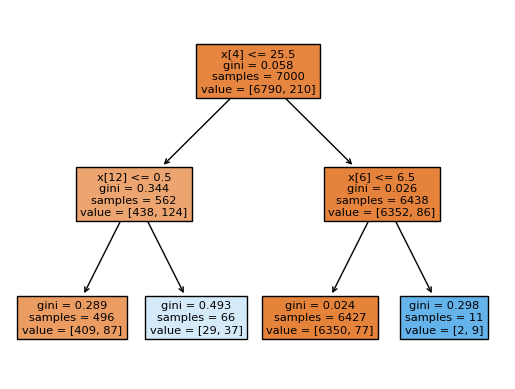

In [17]:
plot_tree(mdl, filled=True)

In [11]:
target_df = pd.read_csv('../detector_shield_nonzero_covariate_target.csv')
target_df

,C#X1,C#X2,C#X3,C#X4,C#X5,C#X6,C#X7,C#X8,C#X9,C#X10,...,C#X21,C#X22,C#X23,C#X24,C#X25,C#X26,C#X27,C#X28,C#X29,cD#detect
0,3.0,0.0,0.0,1.0,30000.0,3.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2.0,0.0,0.0,2.0,1036.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,0.0,0.0,2.0,30000.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,30000.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,3.0,30000.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,1.0,0.0,0.0,2.0,30000.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6996,1.0,0.0,0.0,3.0,145.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6997,2.0,0.0,0.0,3.0,31.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6998,2.0,0.0,0.0,1.0,69.0,3.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [14]:
feature_names = pd.read_csv(grouping_data)['var_name'].to_list()
feature_names

['plannedfx',
 'srssbrt',
 'coursedx_Malignant.neoplasm.of.brain',
 'age',
 'lastadmit',
 'lasted',
 'numyeared',
 'rec_Immunosuppressive.Agents.x',
 'Accidental.Exposure.To.Other.Specified.Factors',
 'Disorders.Of.Muscles',
 'Estrogen.Receptor.Status',
 'Inflammatory.Polyarthropathies',
 'Malignant.Neoplasms.Of.Lip..Oral.Cavity.And.Pharynx',
 'Malignant.Neoplasms.Of.Male.Genital.Organs',
 'cur_Antimetabolites..Antineoplastic',
 'cur_Bone.Density.Conservation.Agents',
 'cur_Dopamine.Antagonists',
 'cur_Serotonin.Antagonists',
 'cur_Vitamins',
 'rec_Dopamine.D2.Receptor.Antagonists',
 'rec_Vasodilator.Agents',
 'BUN',
 'proc_Tracheoscopy.and.laryngoscopy.with.biopsy..35..',
 'cpt_ALBUMIN.SERUM',
 'cpt_ANCHOR',
 'cpt_DOC.ANTIBIO.GIVEN.B.4.SURG',
 'cpt_POST.OP.FOLLOW.UP.VISIT',
 'cpt_THER.PROPH.DIAG.INJ.IV.PUSH',
 'cpt_X.RAY.EXAM..BREAST.SPECIMEN']

In [17]:
mdl = RandomForestClassifier()
mdl.fit(
    target_df.iloc[:,:-1],
    target_df.iloc[:,-1]
)
pd.DataFrame({'feature': feature_names, 'rf_importance': mdl.feature_importances_}).sort_values(by='rf_importance', ascending=False)

,feature,rf_importance
4,lastadmit,0.182925
6,numyeared,0.114258
0,plannedfx,0.096617
12,Malignant.Neoplasms.Of.Lip..Oral.Cavity.And.Ph...,0.080618
16,cur_Dopamine.Antagonists,0.065737
5,lasted,0.063193
21,BUN,0.061811
3,age,0.047169
20,rec_Vasodilator.Agents,0.036234
27,cpt_THER.PROPH.DIAG.INJ.IV.PUSH,0.026527


In [14]:
cols = ["C#X%d" % (i+1) for i in np.arange(targetX.shape[1])] + ["cD#detect"]
df = pd.DataFrame(np.concatenate([
    targetX,
    target_mask.astype(int).reshape(-1,1)
], axis=1), columns=cols)
# df.to_csv('detector_dim4_norm2_stdshiftfirstvar.csv', index=False)
# df.to_csv('detector_readmission_ucsf_zsfg_covariate.csv', index=False)
# df.to_csv('detector_acs_pubcov_covariate.csv', index=False)
# df.to_csv('detector_acs_pubcov_save_scaled_revise.csv', index=False)
df.to_csv('detector_shield_nonzero_covariate_target.csv', index=False)

In [15]:
cols = ["C#X%d" % (i+1) for i in np.arange(targetX.shape[1])] + ["cD#detect"]
df = pd.DataFrame(np.concatenate([
    sourceX,
    source_mask.astype(int).reshape(-1,1)
], axis=1), columns=cols)
# df.to_csv('detector_source_acs_pubcov_covariate.csv', index=False)
# df.to_csv('detector_source_acs_pubcov_save_scaled_revise.csv', index=False)
# df.to_csv('detector_source_readmission_icsf_zsfg_covariate.csv', index=False)
df.to_csv('detector_shield_nonzero_covariate_source.csv', index=False)

In [ ]:
acc_detected_source = get_acc_auc(ml_mdl, sourceX[source_mask], sourceY[source_mask])
pd.DataFrame(acc_detected_source)

,acc,acc_lower,acc_upper,auc,auc_lower,auc_upper
0,0.895206,0.874025,0.916388,0.843898,0.799017,0.885612


In [ ]:
acc_detected_target = get_acc_auc(ml_mdl, targetX[target_mask], targetY[target_mask])
pd.DataFrame(acc_detected_target)

,acc,acc_lower,acc_upper,auc,auc_lower,auc_upper
0,0.704762,0.647619,0.761905,0.526556,0.43584,0.618699


In [ ]:
# Difference in accuracy of the detected subgroup
acc_detected_target['acc'][0] - acc_detected_source['acc'][0]

-0.19044433827042517

In [33]:
def get_subgroup(X):
    subgroup_idx = ((X[:,0]>=0.5) & (X[:,12]>=0.5) & (X[:,16]>=0.5)) | ((X[:,0]>=0.5) & (X[:,1]<0.5) & (X[:,4]<29.5) & (X[:,28]<0.5))
    print("subgroup size %d prevalence %.3f" % (sum(subgroup_idx), sum(subgroup_idx)/len(X)))
    return subgroup_idx
    
subgroup_idx = get_subgroup(targetX)
subgroup_targetX = targetX[subgroup_idx]
subgroup_targetY = targetY[subgroup_idx]
print(len(subgroup_targetX), len(subgroup_targetX)/len(targetX))

subgroup size 498 prevalence 0.071
498 0.07114285714285715


In [34]:
subgroup_idx = get_subgroup(sourceX)
acc_detected_set_source = get_acc_auc(ml_mdl, sourceX[subgroup_idx], sourceY[subgroup_idx])
pd.DataFrame(acc_detected_set_source)

subgroup size 733 prevalence 0.120


,acc,acc_lower,acc_upper,auc,auc_lower,auc_upper
0,0.738063,0.706685,0.770805,0.582606,0.53467,0.628029


In [35]:
subgroup_idx = get_subgroup(targetX)
acc_detected_set_target = get_acc_auc(ml_mdl, targetX[subgroup_idx], targetY[subgroup_idx])
pd.DataFrame(acc_detected_set_target)

subgroup size 498 prevalence 0.071


,acc,acc_lower,acc_upper,auc,auc_lower,auc_upper
0,0.817269,0.785141,0.851406,0.61344,0.5509,0.674673


In [86]:
np.random.seed(1)
train_sourceX, train_sourceY = sourceX, sourceY
train_targetX, test_targetX, train_targetY, test_targetY = train_test_split(
    targetX, targetY, test_size = SPLIT_RATIO
)

In [87]:
def get_detections_covariate(X, detector_lambda, detector_omega):
    source_prob = self._get_source_probability(X)
    exp_loss_source = compute_risk(self.loss_func, X, source_prob)
    odds_on_X = self._get_density_ratio_x(X)

    detections = self._detector_function_covariate_aggregate(exp_loss_source, detector_lambda, odds_on_X, detector_omega)
    return detections

In [88]:
# Accuracy of revised model on all target data
acc_nontargeted = get_acc_auc(ml_mdl, test_targetX, test_targetY)
print("Accuracy on all target\n", pd.DataFrame(acc_nontargeted))

Accuracy on all target
      acc  acc_lower  acc_upper       auc  auc_lower  auc_upper
0  0.688   0.676333   0.699838  0.718504   0.705553    0.73235


In [89]:
# Detected group for nontargeted model on test set
detections_test_target = get_detections_covariate(test_targetX, detector_lambda, detector_omega)
nontargeted_detections_mask = detections_test_target > 0
nontargeted_detections_mask.mean()

0.05566666666666667

In [90]:
# Detected group for targeted model on test set
def get_detections_outcome(explainer_data, X):
    with open(explainer_data, "rb") as f:
        detectors = pickle.load(f)
    detector_y = detectors['agg_detectors_y'][0]
    detection = detector_y.predict(X)
    return detection

In [91]:
# Group addressed by targeted model which is the detected group for original model
targeted_group_mask = get_detections_outcome(targeted_explainer_data, test_targetX) > 0
targeted_group_mask.mean()

0.5071666666666667

In [92]:
# Detections among the data not belonging to the targeted group
detections_from_remaining_mask = ~targeted_group_mask & nontargeted_detections_mask
print("remaining group size %.2f prevalence %.2f" % (sum(detections_from_remaining_mask), detections_from_remaining_mask.mean()))

remaining group size 124.00 prevalence 0.02


In [93]:
# Accuracy of nontargeted revision on detected group in remaining data
acc_remaining_nontargeted = pd.DataFrame(get_acc_auc(
    ml_mdl, 
    test_targetX[detections_from_remaining_mask], 
    test_targetY[detections_from_remaining_mask]
))
print("Accuracy nontargeted revision on detected group in remaining data\n", (pd.DataFrame(acc_remaining_nontargeted) * 100).round(1))

Accuracy nontargeted revision on detected group in remaining data
     acc  acc_lower  acc_upper   auc  auc_lower  auc_upper
0  58.1       50.0       66.9  54.0       42.4       65.3


In [94]:
# Accuracy of original model on detected group in remaining data
acc_remaining_original = pd.DataFrame(get_acc_auc(
    ml_mdl.org_mdl,
    test_targetX[detections_from_remaining_mask],
    test_targetY[detections_from_remaining_mask]
))
print("Accuracy original model on detected group in remaining data\n", (pd.DataFrame(acc_remaining_original) * 100).round(1))

Accuracy original model on detected group in remaining data
     acc  acc_lower  acc_upper   auc  auc_lower  auc_upper
0  77.4       70.2       84.7  75.2       65.2       84.2


Rule:->
If not X1 = (2.04368 - 2.30898) AND not X1 = (2.30898 - 3.40585) AND not X1 >=  3.40585: class = 0
Else : class = True

test report: 
              precision    recall  f1-score   support

           0       0.74      0.96      0.84      1731
           1       0.84      0.35      0.50       909

    accuracy                           0.75      2640
   macro avg       0.79      0.66      0.67      2640
weighted avg       0.77      0.75      0.72      2640

Rule:->
If not X1 >=  1.5: class = 0
Else : class = True

test report: 
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1136
           1       0.99      0.89      0.94      1014

    accuracy                           0.95      2150
   macro avg       0.95      0.95      0.95      2150
weighted avg       0.95      0.95      0.95      2150

Shield nonzero covariate

Rule:->
If not X7 >=  7.5: class = 0
If X2 <  0.5 AND X5 <  29.5 AND X29 <  0.5 AND not X1 <  0.5: class = 1
If X1 >=  0.5 AND not X13 <  0.5 AND not X17 <  0.5: class = 1
Else : class = 0

training report: 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      4547
           1       0.86      0.04      0.08       143

    accuracy                           0.97      4690
   macro avg       0.91      0.52      0.53      4690
weighted avg       0.97      0.97      0.96      4690


test report: 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      2243
           1       0.83      0.07      0.14        67

    accuracy                           0.97      2310
   macro avg       0.90      0.54      0.56      2310
weighted avg       0.97      0.97      0.96      2310

ACS covariate test after removing uncorrelated features

Rule:->
If not X11 <  -5100.0: class = 0
If not X11 = (-5100.0 - 60) AND not X15 = (14.5 - 17.5) AND not X15 >=  19.5: class = 1
If X2 <  19.5 AND X15 = (14.5 - 17.5) AND not X6 <  1.5 AND not X11 = (-5100.0 - 60): class = 1
If X13 <  0.5 AND X15 = (14.5 - 17.5) AND not X4 <  2.5 AND not X6 = (1.5 - 2.5) AND not X11 >=  9715: class = 1
Else : class = 0

In [59]:
# Accuracy
pred = mdl.predict(targetX)
accuracy = accuracy_score(target_mask, pred)
accuracy

0.748875

[Text(0.5, 0.8333333333333334, 'x[0] <= 2.044\ngini = 0.455\nsamples = 8000\nvalue = [5206, 2794]'),
 Text(0.25, 0.5, 'x[1] <= -0.7\ngini = 0.394\nsamples = 6840\nvalue = [4995, 1845]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.494\nsamples = 2558\nvalue = [1421, 1137]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.276\nsamples = 4282\nvalue = [3574, 708]'),
 Text(0.75, 0.5, 'x[3] <= -1.966\ngini = 0.298\nsamples = 1160\nvalue = [211.0, 949.0]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.466\nsamples = 179\nvalue = [113.0, 66.0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.18\nsamples = 981\nvalue = [98, 883]')]

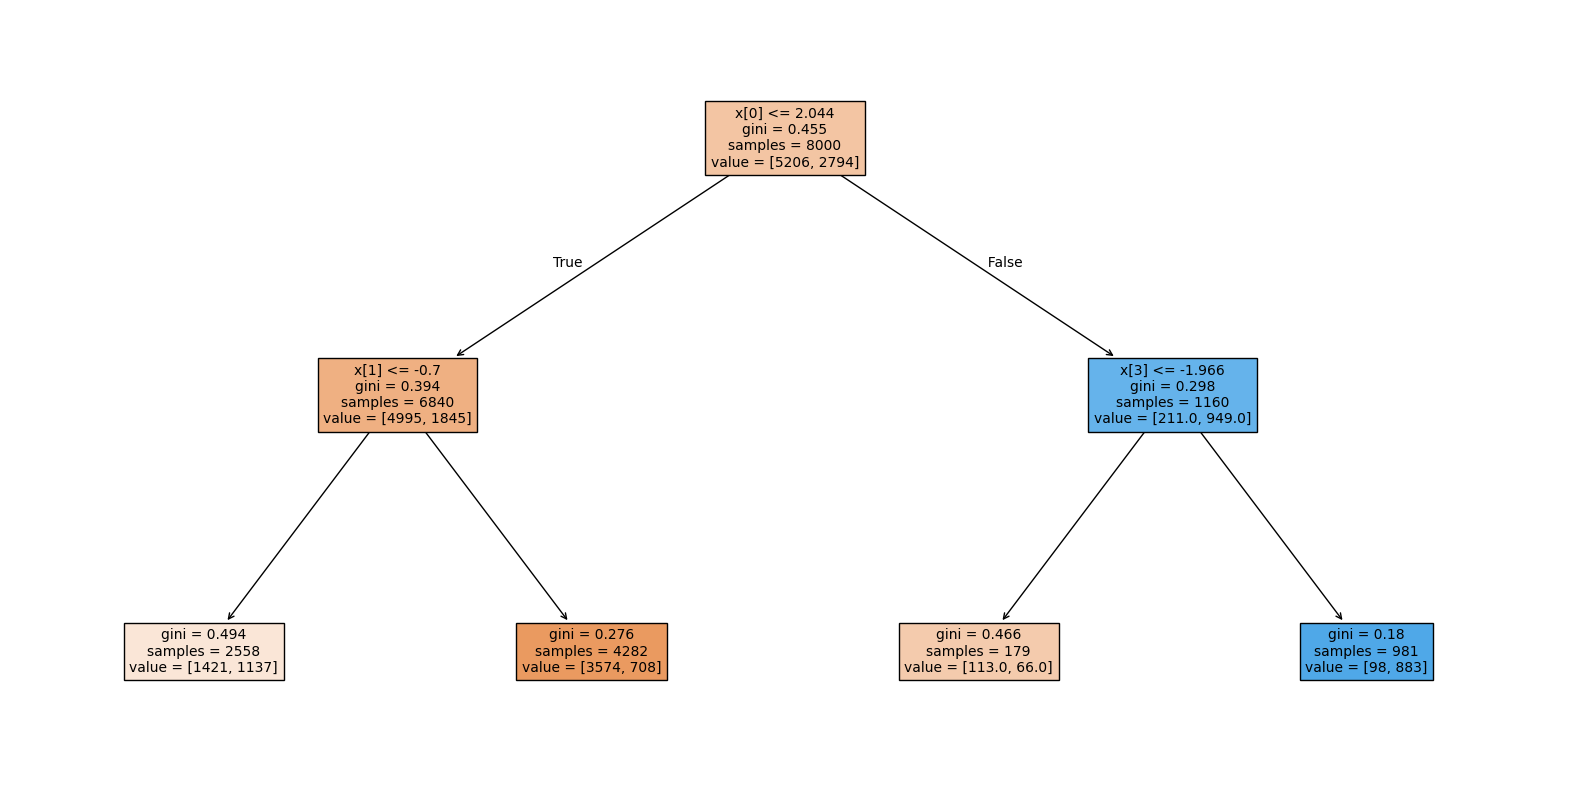

In [60]:
# Visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(mdl, filled=True, fontsize=10)

In [54]:
detectors_y = detectors['agg_detectors_y']

In [ ]:
tree_importance = detectors_y[0].feature_importances_
sorted(list(enumerate(tree_importance)), key = lambda x: x[1], reverse=True)

NameError: name 'detectors_y' is not defined

[Text(0.5, 0.8333333333333334, 'x[0] <= 9.5\nfriedman_mse = 0.147\nsamples = 3257\nvalue = 0.0'),
 Text(0.25, 0.5, 'x[0] <= 1.5\nfriedman_mse = 0.136\nsamples = 3040\nvalue = -0.014'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'friedman_mse = 0.105\nsamples = 1876\nvalue = 0.01'),
 Text(0.375, 0.16666666666666666, 'friedman_mse = 0.185\nsamples = 1164\nvalue = -0.051'),
 Text(0.75, 0.5, 'x[1] <= 56.5\nfriedman_mse = 0.26\nsamples = 217\nvalue = 0.193'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'friedman_mse = 0.241\nsamples = 104\nvalue = 0.369'),
 Text(0.875, 0.16666666666666666, 'friedman_mse = 0.223\nsamples = 113\nvalue = 0.03')]

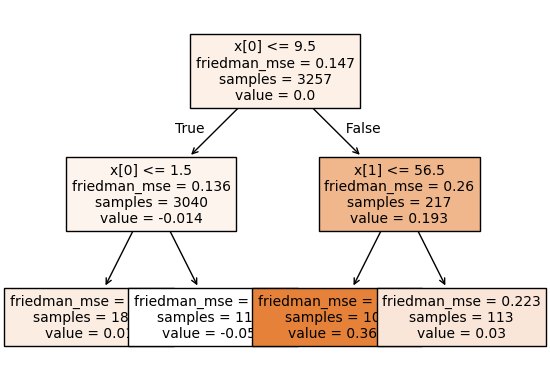

In [14]:
mdl = detectors_y[0].estimators_[0][0]
plot_tree(mdl, filled=True, fontsize=10)

In [15]:
detector = detectors_y[0]
detection_on_targetX = detector.predict(targetX)
target_mask = detection_on_targetX > 0
target_mask

array([ True,  True,  True, ..., False,  True,  True])

In [16]:
np.mean(target_mask)

0.6

In [21]:
targetY[targetX[:,30]>0].mean()

0.5159500693481276

In [23]:
sourceY[sourceX[:,30]>0].mean()

0.21481481481481482

In [17]:
cols = ["C#X%d" % (i+1) for i in np.arange(targetX.shape[1])] + ["cD#detect"]
df = pd.DataFrame(np.concatenate([
    targetX,
    target_mask.astype(int).reshape(-1,1)
], axis=1), columns=cols)
# df.to_csv('detector_dim4_linear_outcome.csv', index=False)
# df.to_csv('detector_acs_pubcov_scaled_outcome.csv', index=False)
# df.to_csv('detector_acs_pubcov_mdl_nocalib_outcome.csv', index=False)
# df.to_csv('detector_acs_pubcov_covariate.csv', index=False)
df.to_csv('detector_readmission_ucsf_zsfg_outcome.csv', index=False)

dim4_linear_std

Rule:->
If not X1 <  -2.43469 AND not X1 = (-2.30891 - -1.2847) AND not X1 = (1.27393 - 2.77756) AND not X1 >=  2.77756 AND not X3 = (-0.296323 - -0.188501) AND not X4 = (1.67039 - 1.9653): class = 0
If not X2 <  -5.11516 AND not X2 >=  5.50351 AND not X3 <  -2.48408 AND not X3 >=  2.89574: class = 1
If not X1 = (1.21361 - 1.27393): class = 0
If not X1 = (-2.43469 - -2.30891) AND not X1 = (-1.2847 - -1.03159) AND not X1 = (-1.03159 - -0.595112) AND not X1 = (-0.595112 - 0.528369) AND not X1 = (0.528369 - 1.21361) AND not X1 = (1.21361 - 1.27393): class = 1
If X3 >=  2.89574 AND not X1 = (-1.03159 - -0.595112) AND not X1 = (0.528369 - 1.21361) AND not X2 = (-2.47991 - -2.00738) AND not X2 = (-0.434374 - 1.67339) AND not X2 = (1.86264 - 2.44021) AND not X2 = (2.44021 - 5.50351) AND not X4 <  -3.80522 AND not X4 >=  1.9653: class = 1
Else : class = 0

training report: 
              precision    recall  f1-score   support

           0       0.76      0.84      0.80      2752
           1       0.81      0.72      0.76      2608

    accuracy                           0.78      5360
   macro avg       0.79      0.78      0.78      5360
weighted avg       0.79      0.78      0.78      5360


test report: 
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      1413
           1       0.79      0.72      0.76      1227

    accuracy                           0.78      2640
   macro avg       0.79      0.78      0.78      2640
weighted avg       0.78      0.78      0.78      2640

acs_pubcov_outcome

Rule:->
If X9 >=  1.5 AND X10 >=  1.5 AND X17 <  0.5 AND not X2 <  17.5 AND not X2 = (50.5 - 59.5) AND not X3 <  1.5 AND not X6 <  3.5 AND not X20 = (1.5 - 11.5) AND not X28 >=  0.5: class = 1
If not X4 = (3.5 - 6.5) AND not X31 >=  0.5: class = 0
If not X4 >=  6.5: class = 1
Else : class = 1

training report: 
              precision    recall  f1-score   support

           0       0.82      0.72      0.77      3932
           1       0.76      0.85      0.80      4108

    accuracy                           0.79      8040
   macro avg       0.79      0.79      0.79      8040
weighted avg       0.79      0.79      0.79      8040


test report: 
              precision    recall  f1-score   support

           0       0.84      0.72      0.77      1990
           1       0.75      0.86      0.80      1970

    accuracy                           0.79      3960
   macro avg       0.79      0.79      0.79      3960
weighted avg       0.79      0.79      0.79      3960

readmission_ucsf_zsfg_outcome

Rule:->
If not X1 = (1.5 - 3.5) AND not X1 = (3.5 - 5.5) AND not X9 >=  5534.43 AND not X15 >=  118.5 AND not X23 >=  5.85: class = 1
If X2 >=  33.5 AND not X9 <  1518.53 AND not X21 <  91.5: class = 0
If not X1 <  1.5 AND not X1 = (5.5 - 9.5) AND not X1 >=  9.5: class = 1
Else : class = 1

training report: 
              precision    recall  f1-score   support

           0       0.42      0.98      0.59      1768
           1       0.87      0.07      0.13      2597

    accuracy                           0.44      4365
   macro avg       0.64      0.53      0.36      4365
weighted avg       0.69      0.44      0.31      4365


test report: 
              precision    recall  f1-score   support

           0       0.40      0.97      0.57       838
           1       0.80      0.08      0.14      1312

    accuracy                           0.43      2150
   macro avg       0.60      0.52      0.36      2150
weighted avg       0.64      0.43      0.31      2150

In [12]:
detection_on_sourceX = detector.predict(sourceX)
source_mask = detection_on_sourceX > 0
source_mask

array([False, False,  True, ..., False,  True, False])

In [13]:
np.mean(source_mask)

0.5884396715097915

In [9]:
def evaluate(model, X, Y):
    Y_pred = model.predict_proba(X)[:,1]
    return ((Y_pred >= 0.5) == Y).mean(), roc_auc_score(Y, Y_pred)

In [37]:
a = np.array([1,2,3,4])
b = np.array([2,2,3,3])
c = np.random.randint(0, 4, (10,4))
d = a[c]
e = b[c]

In [10]:
np.mean(d==e, axis=1)

NameError: name 'd' is not defined

In [16]:
detections = pd.read_csv('/Users/harvineetsingh/Documents/lab/perf_diff_attr/explain_score_test/detector_readmission_ucsf_zsfg_covariate.csv')
target_mask = detections.to_numpy()[:,-1]

In [17]:
target_mask.mean()

0.47014581734458943

In [45]:
def get_subgroup(X):
    # return ((X[:,3]>3.5) & (X[:,3]<4.5)) | (X[:,30]>=0.5)
    return (X[:,0] >= 7)
    
subgroup_idx = get_subgroup(targetX)
subgroup_targetX = targetX[subgroup_idx]
subgroup_targetY = targetY[subgroup_idx]
print(len(subgroup_targetX), len(subgroup_targetX)/len(targetX))

681 0.10452801227935533


In [46]:
np.quantile(targetX[:,0], q=0.9)

7.0

In [47]:
subgroup_idx = get_subgroup(sourceX)
subgroup_sourceX = sourceX[subgroup_idx]
subgroup_sourceY = sourceY[subgroup_idx]
print(len(subgroup_sourceX), len(subgroup_sourceX)/len(sourceX))

192 0.025709694697375468


In [48]:
acc_subgroup_source, auc_subgroup_source = evaluate(ml_mdl, subgroup_sourceX, subgroup_sourceY)
acc_subgroup_source, auc_subgroup_source

(0.5989583333333334, 0.6183076225045372)

In [49]:
acc_subgroup_target, auc_subgroup_target = evaluate(ml_mdl, subgroup_targetX, subgroup_targetY)
acc_subgroup_target, auc_subgroup_target

(0.5653450807635829, 0.5505533769063181)

In [50]:
np.round(acc_subgroup_target - acc_subgroup_source, 3)

-0.034